# SSM-4 — The gate, from none to selective

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/tracks/state-space-models/ssm4-gate-spectrum.ipynb)

**The question:** linear attention, RetNet, S4, Mamba, Gated DeltaNet — how many gates is that, really?

Prerequisites: [SSM-3](ssm3-mamba2-ssd.ipynb), [M4](../../foundations/m4-delta-rule.ipynb), [M7](../../foundations/m7-three-dials.ipynb).

The track turned one dial four times. S4 set the gate to a fixed structured decay, Mamba let each token choose it channel by channel, and Mamba-2 narrowed that choice to a single scalar and watched the recurrence turn into an attention matrix. Every move was on the gate, and every module left the write untouched. This one stops moving and looks back down the axis. Linear attention, RetNet, S4, Mamba, GLA, Gated DeltaNet and KDA all run on the same recurrence, and the gate alone tells most of them apart. Read across its range, from a gate that does nothing to one that fades the memory per channel at the token's command, and that list of names becomes five settings of one number. The write rule supplies a second axis, the additive-or-delta choice M4 turned, and the two together make a grid with a slot for every model here.

> Grounding: a synthesis of the track and the foundations. The map is M7 §5's write-rule zoo read down its gate column, with the delta-side rows from M4 §6. Its two named-but-not-built anchors, [RetNet](https://arxiv.org/abs/2307.08621) (Sun et al., 2023) and [GLA](https://arxiv.org/abs/2312.06635) (Yang et al., 2023), are checked against their own papers below; every other model is cited to the module that builds it.

## Objective

After this module you should be able to:

- Read the gate as one axis with two questions behind it: does the decay depend on the input, and does it act as one scalar or one factor per channel. Name the setting at each rung: none ([M3](../../foundations/m3-linear-attention.ipynb) linear attention), fixed scalar (RetNet), fixed structured diagonal (S4), input-dependent scalar (Mamba-2), input-dependent channel-wise (Mamba, GLA).
- Add the write dial from [M4](../../foundations/m4-delta-rule.ipynb) as a second axis, additive against delta, and place the DeltaNet family beside the SSMs on the resulting grid: DeltaNet at delta with no gate, Gated DeltaNet at delta with a scalar gate, KDA at delta with a channel-wise gate.
- Run one parametrized recurrence with the gate set three ways and watch the gate value, and nothing else, change what the memory keeps.
- Recover M3's linear attention at gate $1$ and SSM-3's masked-attention output at a scalar gate as exact numerical identities, which anchor the axis to the modules that built its endpoints.
- Read the whole picture as two of [M7](../../foundations/m7-three-dials.ipynb)'s three dials, and say why the third, the optimizer, is the one this track never turned.

## Why it exists (the role it plays)

Every earlier module in this track repaired the one before it. S4's fixed gate could not select, so Mamba made it input-dependent; Mamba lost the convolution, so Mamba-2 restricted the gate to a scalar and bought back a closed form. This module repairs nothing. It stops adding and starts organizing.

The reason to stop is that the track has quietly built a coordinate rather than a chain. Four modules moved a single dial across its range, and the range holds more than the four points the track happened to land on. RetNet sits between linear attention and S4. GLA sits beside Mamba. Gated DeltaNet and KDA sit one axis over, on the delta write. Left as a list, these are seven papers with seven notations. Placed on the gate axis with the write axis crossing it, they are a grid you can read in one glance, and the grid is the one M7 drew as its write-rule zoo, now filled in and sorted by the dial this track turns.

That is the role a synthesis module plays. It does not add a mechanism; it fixes where the mechanisms you already have sit relative to each other, so the next paper you meet arrives with a coordinate instead of a fresh vocabulary.

### Reading

- [Nested Learning](https://arxiv.org/abs/2512.24695) §5 for the master recurrence and the gate settings it lists ("*either is 1, learnable, channel-wise, and/or input-dependent*"); the map here is [M7](../../foundations/m7-three-dials.ipynb) §5's zoo read down that gate column. The delta-side members are M4 §4 and §6 (DeltaNet, Gated DeltaNet, KDA). The two anchors checked against their own papers are [RetNet](https://arxiv.org/abs/2307.08621) (Sun et al., 2023) §2.1 Eq. 6 and §2.2 Eq. 8, for a decay $\gamma$ that is a fixed scalar per head, and [GLA](https://arxiv.org/abs/2312.06635) (Yang et al., 2023) §4.1 Eq. 3, for a data-dependent gate that acts per channel. The SSM rungs are cited to the modules that build them: S4 to SSM-1, Mamba to SSM-2, Mamba-2 to SSM-3.

## 1. The gate axis, from none to channel-wise

The master recurrence is the one M7 wrote and the track has been setting:

$$\mathbf{S}_t=\alpha_t\,\mathbf{S}_{t-1}+\beta_t\,(\text{write}_t)\,\phi(\mathbf{k}_t)^\top,\qquad \mathbf{o}_t\propto\mathbf{S}_t\,\phi(\mathbf{q}_t).$$

The gate is $\alpha_t$, the factor that multiplies the old memory before the new write lands (M7 §2, dial 2). It is the only term that touches what is already stored, so it alone decides what fades. Reading it across its range means asking two questions of that factor, and the two are independent.

First, does $\alpha_t$ depend on the input? A gate fixed at training time applies the same decay schedule to every sequence. An input-dependent gate lets the current token set the decay, which is what SSM-2 called selectivity.

Second, is $\alpha_t$ one number or many? A scalar gate fades the whole state by a single factor. A channel-wise gate carries one factor per coordinate of the state, so it can hold some directions and drop others in the same step. The two write as $\alpha_t\mathbf{S}_{t-1}$ and $\mathrm{diag}(\boldsymbol\alpha_t)\mathbf{S}_{t-1}$.

Two yes-or-no questions make four corners, plus the origin where the gate is switched off. Each is a named model.

- **None, $\alpha_t=1$.** Nothing fades; the memory only appends. This is M3 linear attention, the Hebbian memory the whole course starts from ([linear attention](https://arxiv.org/abs/2006.16236), Katharopoulos et al., 2020).
- **Fixed, scalar.** A single constant $\gamma\in(0,1)$ fades everything by the same factor every step, set once and shared across the sequence. This is [RetNet](https://arxiv.org/abs/2307.08621)'s retention, $\mathbf{S}_n=\gamma\mathbf{S}_{n-1}+\mathbf{k}_n^\top\mathbf{v}_n$ with $\gamma$ a fixed scalar, and a different fixed $\gamma$ per head for a spread of timescales (RetNet §2.1 Eq. 6, §2.2 Eq. 8).
- **Fixed, channel-wise.** A structured diagonal $\bar A$, set at training time, gives each mode its own fixed decay. This is S4, the model SSM-1 built: the gate is $\alpha_t=\bar A$, and the reason it is structured rather than random is that a random diagonal forgets ([S4](https://arxiv.org/abs/2111.00396), Gu et al., 2021).
- **Input-dependent, scalar.** One number per token, chosen by the token, fading the entire state. This is Mamba-2, the model SSM-3 built: $\alpha_t=a_t$ with $a_t=\exp(\Delta_t A)$ a function of the input, restricted to a scalar so the recurrence keeps its attention form ([Mamba-2](https://arxiv.org/abs/2405.21060) §5.1).
- **Input-dependent, channel-wise.** One factor per coordinate, each chosen by the token. This is Mamba, the model SSM-2 built, where $\bar A_t=\exp(\Delta_t A)$ is diagonal and input-dependent ([Mamba](https://arxiv.org/abs/2312.00752) §3). It is also GLA, reached from the linear-attention side rather than the state-space side: its gate is a vector $\boldsymbol\alpha_t\in(0,1)^{d_k}$ produced by a low-rank map and a sigmoid on the token, applied as $\mathrm{diag}(\boldsymbol\alpha_t)$ (GLA §4.1 Eq. 3, §4.4).

The last rung is where the two families the track has been joining meet once more. GLA arrives from M3's linear attention by attaching a forget gate to the Hebbian write; Mamba arrives from SSM-1's state space by making the diagonal transition input-dependent. They land on the same setting, an additive write with an input-dependent per-channel gate. GLA's own paper draws the map from its side: it describes Mamba-2 as the more restricted case with a scalar gate $\gamma_t\mathbf{1}\mathbf{1}^\top$ in place of GLA's per-channel one (GLA §4.1), which is exactly the step from this rung up to the one above it.

::: {.callout-note collapse="true"}
## Q: Is the gate really one axis, or a 2-by-2 grid dressed as a line?

Two independent bits, input-dependence and granularity, make four settings, so the picture is a 2-by-2 with an off corner, not a totally ordered line. RetNet's fixed scalar and S4's fixed diagonal are not one strictly above the other; they differ on the granularity bit while sharing the fixed bit. Same for Mamba-2 and Mamba on the input-dependent side.

The line in §1 is a reading path through those corners, chosen so each step adds one capability: switch the gate on (none to fixed scalar), let it act per channel (to fixed diagonal), let the token set it (to input scalar), then both at once (to input channel-wise). It is a tour, not a ranking, and the demo in §3 slides along it precisely because the endpoints, gate $1$ and a scalar gate, are the exact recurrences M3 and SSM-3 already pinned down.
:::

## 2. The second axis: the write, and the map it completes

The gate is one dial. The write rule is a different one, and it is the axis that separates the SSM family from the DeltaNet family.

The write is the vector paired with the key in the outer product (M7 §2, dial 1). Two choices matter here. The **additive** or Hebbian write stores the value as handed in, $\text{write}_t=\mathbf{v}_t$, and never reads the memory first (M1, M3). The **delta** write reads the memory at the current key and stores only the error, $\text{write}_t=\mathbf{v}_t-\mathbf{S}_{t-1}\phi(\mathbf{k}_t)$, so a revisited key is edited rather than piled onto (M4 §3). Every SSM in this track uses the additive write; DeltaNet and its descendants use the delta write. That choice, not the gate, is what makes them different families.

Now cross the two axes. The gate runs down the rows, from no gate to an input-dependent per-channel gate; the write runs across the columns, additive or delta. Every model the course has named lands in one cell.

| gate $\alpha_t$ ↓  ·  write → | **additive** $\;\mathbf{v}_t$ | **delta** $\;\mathbf{v}_t-\mathbf{S}_{t-1}\phi(\mathbf{k}_t)$ |
|---|---|---|
| **none** $\;\alpha_t=1$ | linear attention | DeltaNet |
| **fixed scalar** $\;\gamma$ | RetNet | — |
| **fixed diagonal** $\;\bar A$ | S4 | — |
| **input-dep. scalar** $\;a_t$ | Mamba-2 | Gated DeltaNet |
| **input-dep. channel-wise** $\;\mathrm{diag}(\boldsymbol\alpha_t)$ | Mamba / S6, GLA | KDA |

Read down the additive column and you get this track, S4 to Mamba, one move per row. Read down the delta column and you get the DeltaNet family: DeltaNet with no gate, Gated DeltaNet once a scalar gate is added, KDA once that gate goes channel-wise (M4 §4, §6). The two columns are the same ladder of gates built on two different writes, which is why Gated DeltaNet reads as the RetNet-and-Mamba-2 gate on a delta write and KDA as the Mamba gate on a delta write. The gate axis this track turned is the axis the DeltaNet family climbs too; only the write underneath it differs. The empty cells are real gaps: the course names no model with a fixed, data-independent gate on a delta write.

## 3. One recurrence, the gate set three ways

The grid claims the gate is a real axis, a single argument you can slide with named models at its settings. To check that, build one recurrence, hold the write and the keys and values fixed, and move only the gate. If the axis is real, gate $1$ should reproduce M3's linear attention exactly, a scalar gate should reproduce SSM-3's masked-attention output exactly, and a channel-wise gate should give a memory neither of those can.

The recurrence is the master one with the gate passed in. When the gate is a length-$T$ vector of per-step scalars it fades the whole state; when it is a $T\times N$ array it fades each of the $N$ state channels on its own. Everything else is held constant.

In [1]:
import torch

torch.manual_seed(0)
T, N, P = 12, 4, 3          # sequence length; state/key dim N; value dim P

B = torch.randn(T, N)       # key map   B_t  (phi(k_t))
C = torch.randn(T, N)       # query map C_t
X = torch.randn(T, P)       # values / inputs

def recurrence(B, C, X, gate, write="hebb"):
    # M7's master recurrence with the gate passed in (same shape as SSM-3's).
    # S_t = alpha_t (.) S_{t-1} + write_t B_t^T ;  y_t = C_t^T S_t .  State S is N x P.
    # gate[t] is a scalar (fade the whole state) or a length-N vector (fade each channel).
    S = torch.zeros(N, P)
    Y = torch.zeros(T, P)
    for t in range(T):
        g = gate[t]
        g = g[:, None] if g.dim() == 1 else g                # channel-wise -> broadcast over values
        w = X[t] if write == "hebb" else X[t] - (B[t] @ S)   # additive (Hebbian) vs delta (M4)
        S = g * S + torch.outer(B[t], w)
        Y[t] = C[t] @ S
    return Y

def decay_mask(a):
    # L_ij = prod_{k=j+1..i} a_k for j <= i (SSM-3's 1-semiseparable decay mask).
    cum = torch.cumsum(torch.log(a), dim=0)
    return torch.tril(torch.exp(cum[:, None] - cum[None, :]))

G = C @ B.t()                                                # score table G_ij = C_i . B_j

# gate = 1 (none): the recurrence must be M3 linear attention exactly
Y_none = recurrence(B, C, X, gate=torch.ones(T), write="hebb")
Y_m3   = (torch.tril(torch.ones(T, T)) * G) @ X
assert torch.allclose(Y_none, Y_m3, atol=1e-5)
print("gate = 1         -> M3 linear attention    | max diff", f"{(Y_none - Y_m3).abs().max():.1e}")

# gate = scalar a_t (input-dependent): must be SSM-3's masked linear attention exactly
a = torch.sigmoid(torch.randn(T))                            # one scalar gate per token, in (0,1)
Y_scalar = recurrence(B, C, X, gate=a, write="hebb")
Y_ssd    = (decay_mask(a) * G) @ X                           # y = (L o (C B^T)) X, SSM-3 section 2
assert torch.allclose(Y_scalar, Y_ssd, atol=1e-5)
print("gate = a_t       -> SSM-3 masked attention | max diff", f"{(Y_scalar - Y_ssd).abs().max():.1e}")

# gate = channel-wise vector: a memory neither special case can express
Achan = torch.sigmoid(torch.randn(T, N))                    # one gate per state channel, per token
Y_chan = recurrence(B, C, X, gate=Achan, write="hebb")
print("gate = diag(a_t) -> channel-wise SSM       | differs from the scalar gate by",
      f"{(Y_chan - Y_scalar).abs().max():.2f}")

gate = 1         -> M3 linear attention    | max diff 1.2e-06
gate = a_t       -> SSM-3 masked attention | max diff 1.9e-06
gate = diag(a_t) -> channel-wise SSM       | differs from the scalar gate by 7.82


The two asserts hold to floating-point tolerance, so the endpoints of the axis are not analogies. At gate $1$ the recurrence is M3's linear attention exactly, the append-only memory with no forgetting. At a per-token scalar gate it is SSM-3's masked linear attention exactly, the decay-masked $CB^\top$ that module derived from Mamba-2's scalar restriction. One function, one argument apart, sits at two named points the course reached from opposite directions. The channel-wise run is a third memory neither endpoint can produce, because a single number cannot fade one state channel while holding another; the last print shows the two outputs are simply different functions of the same inputs.

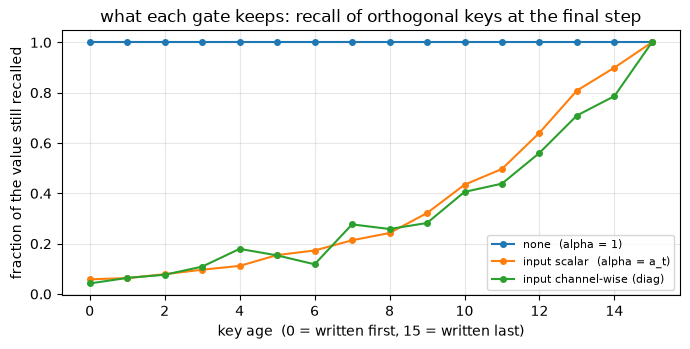

In [2]:
import matplotlib.pyplot as plt

# One retention task, three gates. Orthogonal keys, so recall is exact and the gate is the
# only thing acting: write value v_i at key e_i, then read every key back at the final step.
torch.manual_seed(3)
Tr = 16
keys = torch.eye(Tr)                       # e_0 ... e_{Tr-1}: orthonormal, so state dim N = Tr
vals = torch.randn(Tr, P)

gates = {
    "none  (alpha = 1)":            torch.ones(Tr),
    "input scalar  (alpha = a_t)":  torch.sigmoid(torch.randn(Tr)) * 0.25 + 0.70,      # per token
    "input channel-wise (diag)":    torch.sigmoid(torch.randn(Tr, Tr)) * 0.25 + 0.70,  # per channel
}

fig, ax = plt.subplots(figsize=(7, 3.6))
for name, gate in gates.items():
    S = torch.zeros(Tr, P)
    for t in range(Tr):
        g = gate[t]; g = g[:, None] if g.dim() == 1 else g
        S = g * S + torch.outer(keys[t], vals[t])
    retained = torch.stack([(keys[i] @ S).norm() / vals[i].norm() for i in range(Tr)])
    ax.plot(range(Tr), retained.tolist(), marker="o", ms=4, label=name)

ax.set_xlabel("key age  (0 = written first, 15 = written last)")
ax.set_ylabel("fraction of the value still recalled")
ax.set_title("what each gate keeps: recall of orthogonal keys at the final step")
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

The three curves share every key, every value and every readout; only the gate differs, and the memory keeps something different in each. With no gate the memory recalls every key at full strength no matter how old, which is linear attention's append-only behaviour and, past a point, its failure mode. The input scalar gate fades recall smoothly with age: every channel shares one per-step factor, so a key's retention is set by how long ago it was written and nothing else. The channel-wise gate breaks that tie. Its curve is jagged because each key rides its own channel's accumulated gate, so two keys written the same distance back are kept and dropped differently, which is the content-dependent forgetting selectivity buys. The axis in §1 is this plot: one argument, slid from the top curve to the bottom, is the difference between the models the grid names.

**Scope.** This is a map, not a benchmark. The two asserts settle exact identities, that gate $1$ is M3's linear attention and a scalar gate is SSM-3's masked attention, and the plot shows three gate settings producing visibly different retention on one synthetic recall task with orthogonal keys at $T=16$. It locates models on the gate axis; it ranks nothing. Nothing here compares Mamba to GLA on a real task, measures speed, or trains a parameter: the named models differ in how their gates and writes are parameterized and learned at scale, which this toy either holds fixed or sets by hand. What the toy does establish is the module's one claim, that the gate is a single real axis with the course's models at settings of it, and that its endpoints are the exact recurrences earlier modules built.

## 4. Two of the three dials

Step back and the grid is not new. Its two axes are two of M7's three dials. The columns are dial 1, the write rule, the axis M4 turned from additive to delta. The rows are dial 2, the gate, the axis this track turned from none to channel-wise. The whole track has been filling in one face of the three-dial coordinate M7 laid out, the face where the write stays additive and the gate sweeps its range, while M4's family fills in the neighbouring face where the write is delta.

The third dial, the optimizer, is the one nothing in this track touched. Every model on the grid applies its write in a single plain step at some rate $\beta_t$ (M7 §2, dial 3). Turn that dial and the write can take many steps, carry momentum, or precondition, which is where the memory stops being a matrix and becomes a small network trained at inference time. That is another track's departure point, not this one's.

So the placement of any model here is three coordinates: a write, a gate, and an optimizer.

| Model | write | gate | optimizer |
|---|---|---|---|
| linear attention | additive | none | plain step, rate $1$ |
| RetNet | additive | fixed scalar $\gamma$ | plain step, rate $1$ |
| S4 | additive | fixed diagonal $\bar A$ | plain step, rate $1$ |
| Mamba-2 | additive | input scalar $a_t$ | plain step, rate $1$ |
| Mamba / S6, GLA | additive | input channel-wise | plain step, rate $1$ |
| DeltaNet | delta | none | plain step, rate $\beta_t$ |
| Gated DeltaNet | delta | input scalar | plain step, rate $\beta_t$ |
| KDA | delta | input channel-wise | plain step, rate $\beta_t$ |

The optimizer column is constant down the whole table: every model here lives at one setting of dial 3, a single plain step. That is the map's edge. Name those three coordinates — write, gate, and optimizer — and any model you meet after this course arrives already half-read, because you have turned each dial by hand and watched what it does.

## Exit check

You have the map when you can:

1. Say the gate's two questions, whether it depends on the input and whether it is scalar or channel-wise, and name the model at each setting: linear attention at none, RetNet at fixed scalar, S4 at fixed diagonal, Mamba-2 at input scalar, Mamba and GLA at input channel-wise.
2. Add the write axis and place the delta family beside the SSMs: DeltaNet, Gated DeltaNet and KDA are the none, scalar and channel-wise gates built on a delta write instead of an additive one.
3. Explain why gate $1$ is exactly M3's linear attention and a scalar gate is exactly SSM-3's masked attention, and why a channel-wise gate is a memory neither can express.
4. Read the grid as two of M7's three dials, and say why the optimizer, the third, is the one this track left alone.

**Next →** back to [M7 — the three dials](../../foundations/m7-three-dials.ipynb), the coordinate system this track has been filling in. The gate column of its write-rule zoo (§5) is the axis this track walked; the [hybrid-models aside](ssm4-aside-hybrid-models.ipynb) steps off it to ask why frontier models still interleave these gated SSM blocks with full attention.